In [1]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import tifffile as tif
import torch.nn.functional as F
import os

In [15]:
# img = plt.imread(r"data\multi-temporal-crop-classification\training_chips\training_chips\chip_184_238_merged.tif")
img = tif.imread(r"data/multi-temporal-crop-classification/training_chips/training_chips/chip_179_520_merged.tif")
img.shape

(224, 224, 18)

In [12]:
img_file = "data/multi-temporal-crop-classification/training_chips/training_chips/chip_179_520_merged.tif"
mask_file = "data/multi-temporal-crop-classification/training_chips/training_chips/chip_179_520.mask.tif"

img = tif.imread(img_file).reshape(224, 224, 6, 3)
mask = tif.imread(mask_file)

layout = np.random.randint(0, 3)
subsection = np.random.randint(0, 224 - 56 + 1, 2)

img = img[subsection[0]:subsection[0]+56, subsection[1]:subsection[1]+56, : , layout]

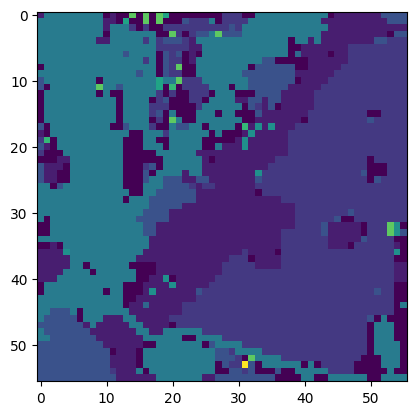

In [24]:
x = mask[42:42+56, 69:69+56]
plt.imshow(x)

In [38]:
np.max((img - np.mean(img)) / np.std(img)), np.min((img - np.mean(img)) / np.std(img))

(np.float64(9.624311814295831), np.float64(-1.3887118914344798))

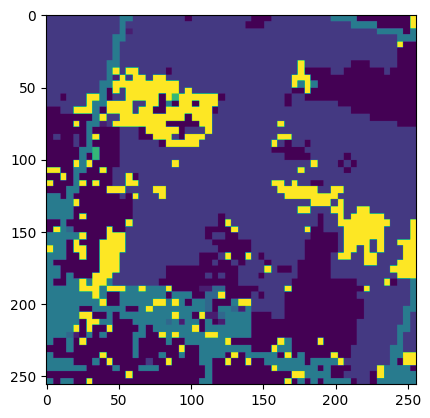

In [73]:
x = tif.imread(r"D:\Documents\ML_Work\MetaLearner_V1\data\crop\train\chip_003_062_mask-0_0.tif")

upscaled_image = cv2.resize(x, (256, 256), interpolation=cv2.INTER_NEAREST)
plt.imshow(upscaled_image)

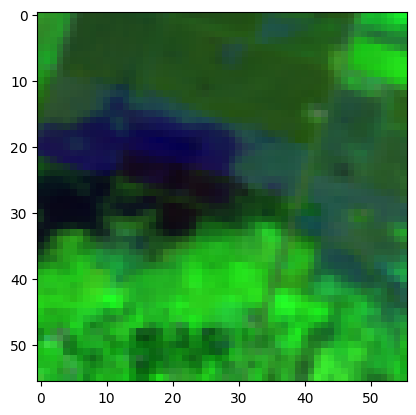

In [89]:
# Function to normalize an image
def normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))

x = tif.imread(r"D:\Documents\ML_Work\MetaLearner_V1\data\crop\train\chip_036_147_img-0_33x9.tif")

# upscaled_image = cv2.resize(x[:,:,3:6], (256, 256), interpolation=cv2.INTER_LINEAR)
plt.imshow(x[:,:,:3])

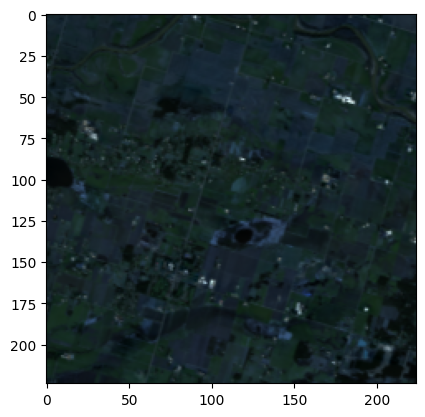

In [97]:
plt.imshow(normalize(x[:,:,:3]))

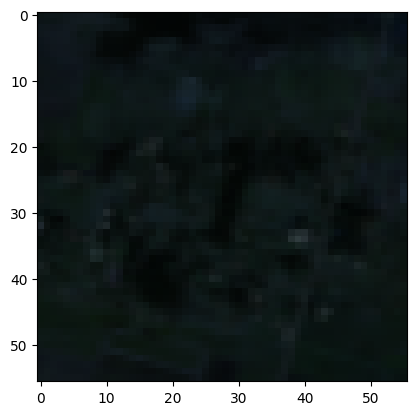

In [98]:
# Function to normalize an image
def normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))

x = tif.imread(r"D:\Documents\ML_Work\MetaLearner_V1\data\multi-temporal-crop-classification\training_chips\training_chips\\chip_003_062_merged.tif")

# upscaled_image = cv2.resize(x[:,:,3:6], (256, 256), interpolation=cv2.INTER_LINEAR)
plt.imshow(normalize(x)[56:112,56:112,:3])


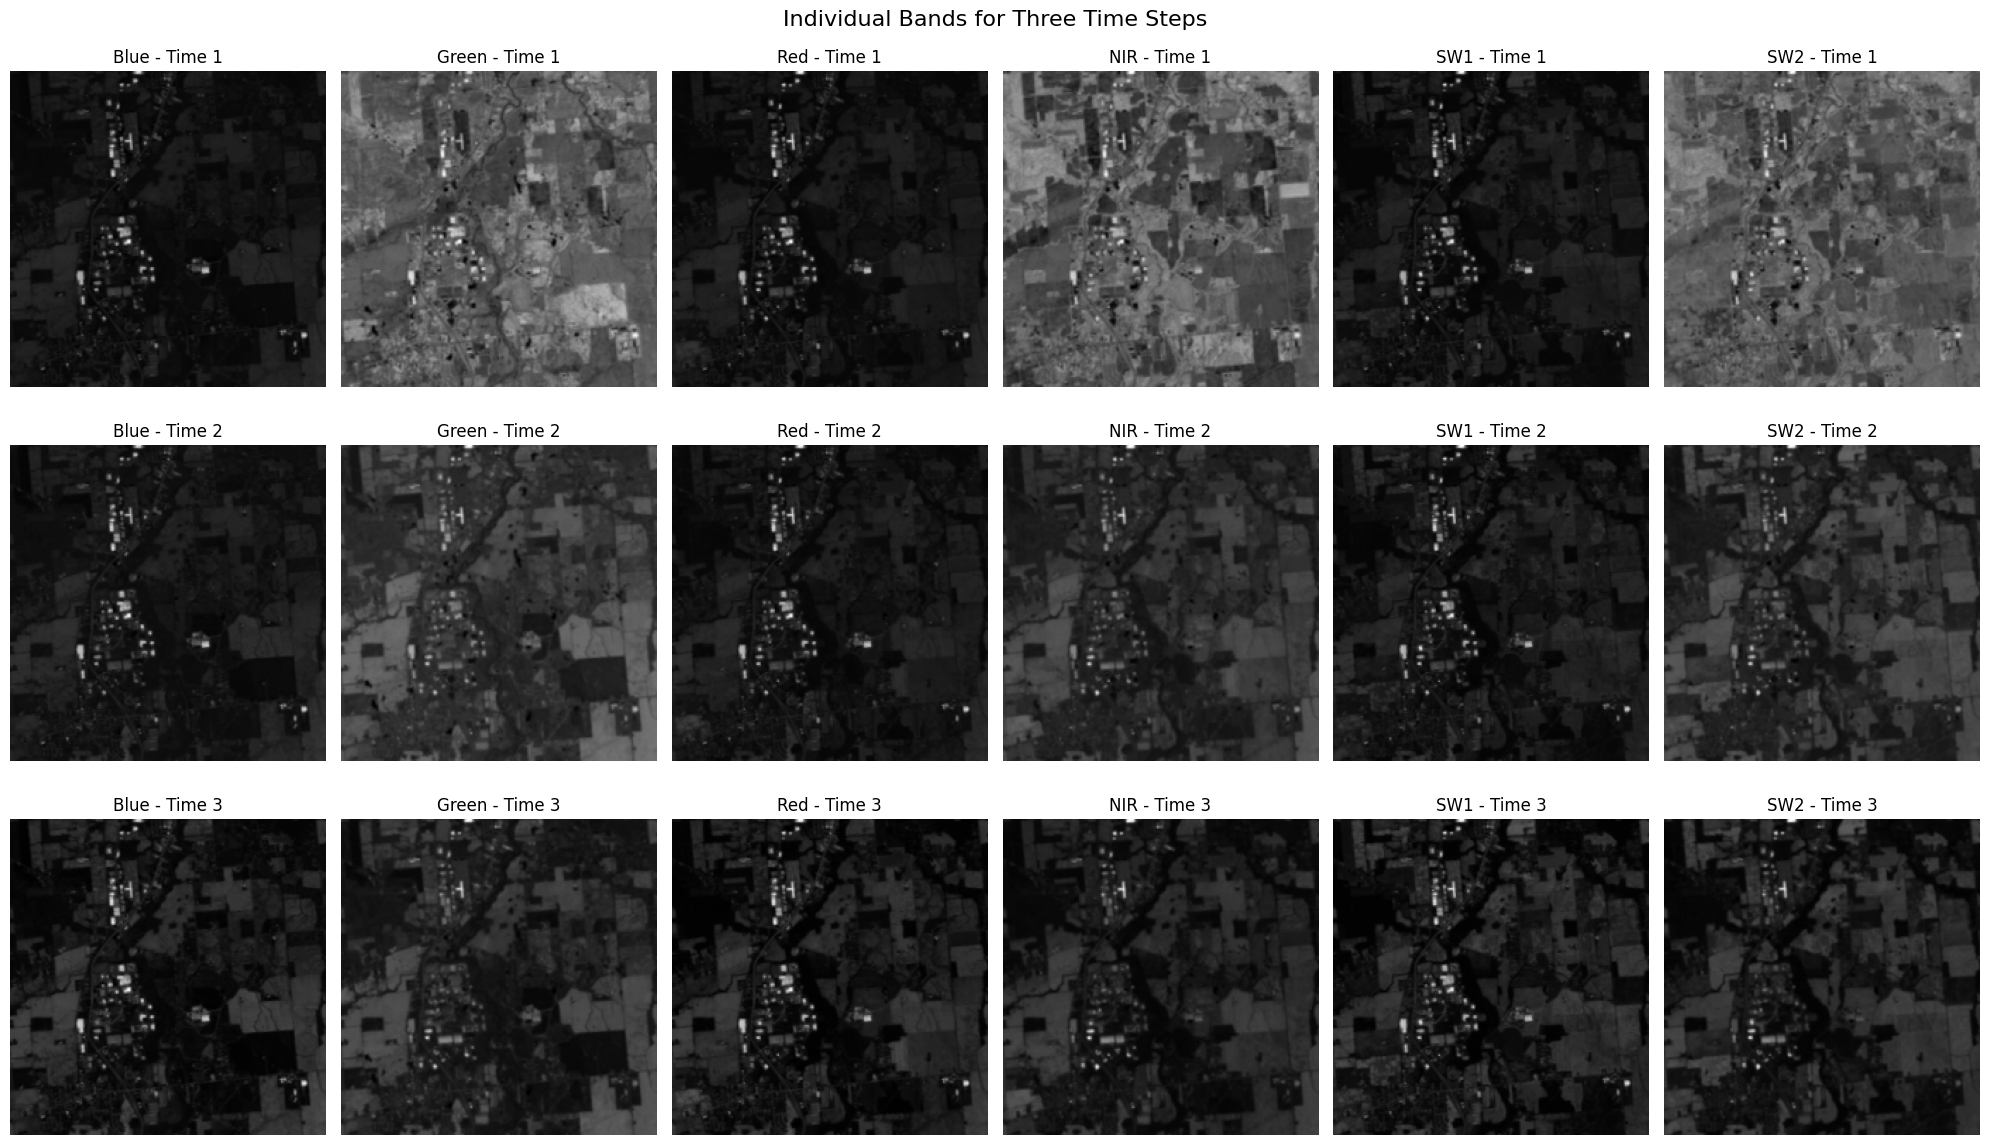

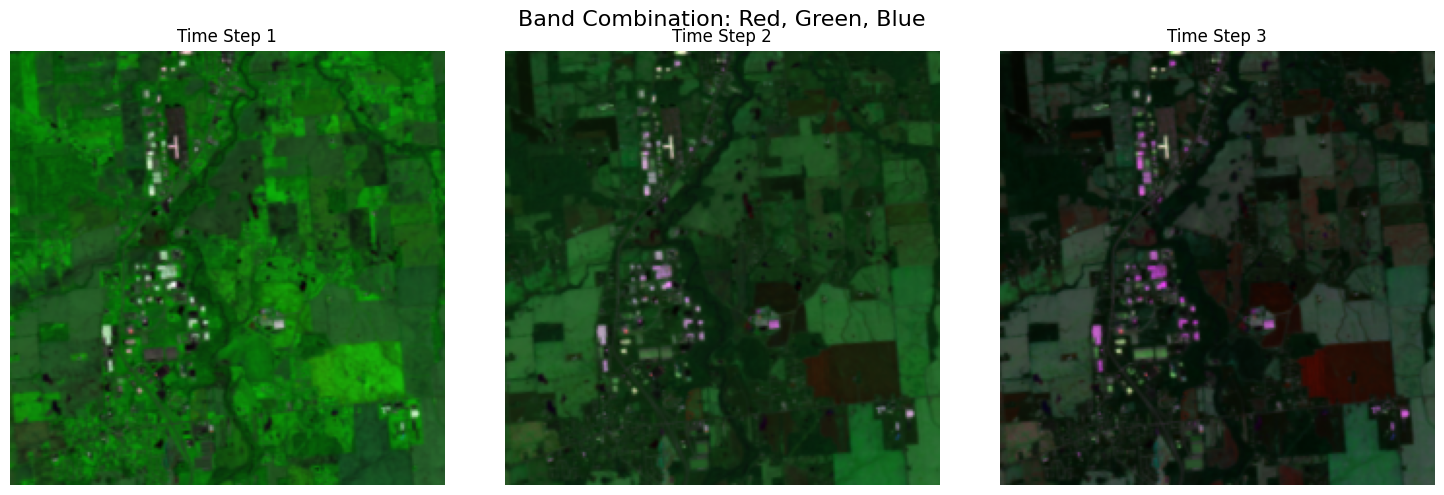

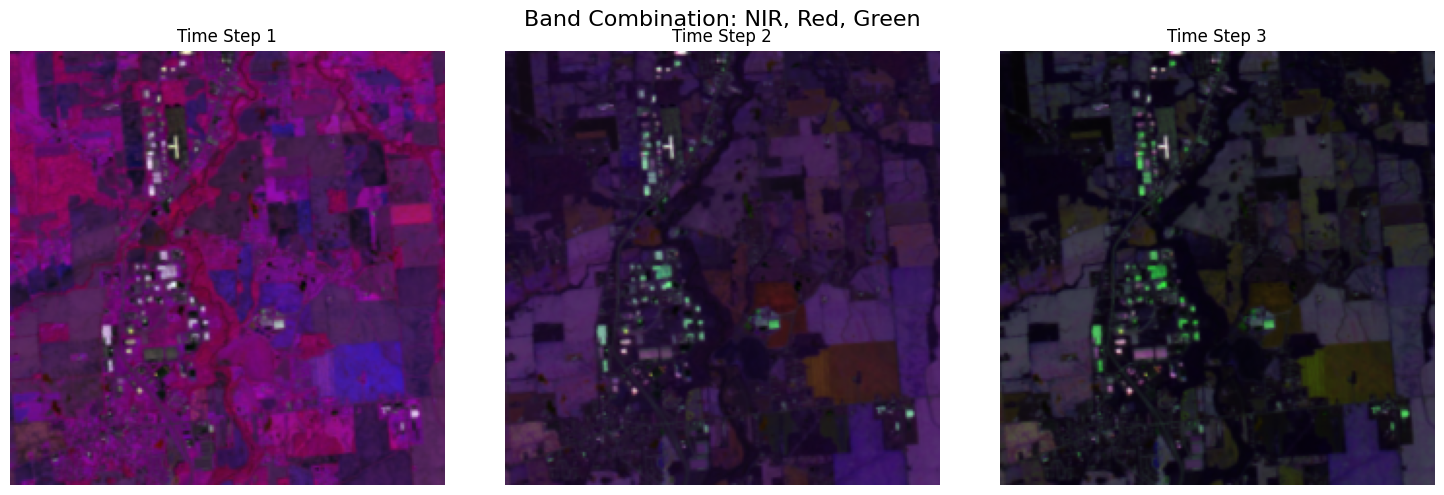

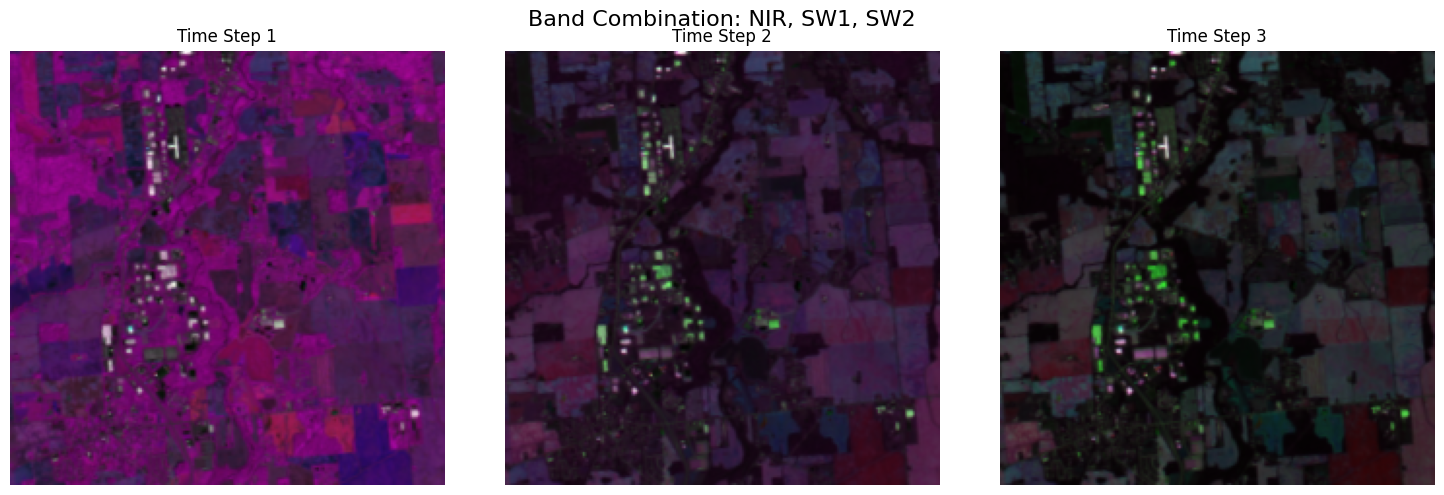

In [16]:
img_reshaped = img.reshape(224, 224, 6, 3)

# Function to normalize an image
def normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))

# Create a 3x6 subplot (3 time steps, 6 bands each)
fig, axs = plt.subplots(3, 6, figsize=(20, 12))
fig.suptitle('Individual Bands for Three Time Steps', fontsize=16)

band_names = ['Blue', 'Green', 'Red', 'NIR', 'SW1', 'SW2']

for t in range(3):  # For each time step
    for b in range(6):  # For each band
        band = img_reshaped[:, :, b, t]
        band_norm = normalize(band)
        axs[t, b].imshow(band_norm, cmap='gray')
        axs[t, b].set_title(f'{band_names[b]} - Time {t+1}')
        axs[t, b].axis('off')

plt.tight_layout()
plt.show()

# Now let's try different band combinations
def display_band_combination(bands, titles):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Band Combination: {titles}', fontsize=16)
    
    for t in range(3):  # For each time step
        combined = np.stack([normalize(img_reshaped[:, :, b, t]) for b in bands], axis=-1)
        axs[t].imshow(combined)
        axs[t].set_title(f'Time Step {t+1}')
        axs[t].axis('off')
    
    plt.tight_layout()
    plt.show()

# Try different band combinations
display_band_combination([2, 1, 0], "Red, Green, Blue")
display_band_combination([3, 2, 1], "NIR, Red, Green")
display_band_combination([3, 4, 5], "NIR, SW1, SW2")

In [117]:
def normalize_hyperspectral_temporal(image):
    # Ensure the input is a numpy array
    image = np.array(image)
    
    # Check if the input shape is correct
    if image.shape != (224, 224, 6, 3):
        raise ValueError("Input image must have shape (224, 224, 6, 3)")
    
    # Create an output array of the same shape
    normalized = np.zeros_like(image, dtype=np.float32)
    
    # Iterate over each spectral band and time step
    for i in range(6):  # 6 spectral bands
        for j in range(3):  # 3 time steps
            slice_2d = image[:, :, i, j]
            min_val = np.min(slice_2d)
            max_val = np.max(slice_2d)
            
            # Avoid division by zero
            if max_val > min_val:
                normalized[:, :, i, j] = (slice_2d - min_val) / (max_val - min_val)
            else:
                normalized[:, :, i, j] = 0  # or you could set it to a constant value
    
    return normalized

def normalize_hyperspectral_temporal_two_part(image):
    # Ensure the input is a numpy array
    image = np.array(image)
    
    # Check if the input shape is correct
    if image.shape != (224, 224, 6, 3):
        raise ValueError("Input image must have shape (224, 224, 6, 3)")
    
    # Create an output array of the same shape
    normalized = np.zeros_like(image, dtype=np.float32)
    
    # Normalize RGB portion (first 3 bands)
    for j in range(3):  # 3 time steps
        rgb_slice = image[:, :, :3, j]
        min_val = np.min(rgb_slice)
        max_val = np.max(rgb_slice)
        if max_val > min_val:
            normalized[:, :, :3, j] = (rgb_slice - min_val) / (max_val - min_val)
        else:
            normalized[:, :, :3, j] = 0
    
    # Normalize hyperspectral portion (last 3 bands)
    for j in range(3):  # 3 time steps
        hyper_slice = image[:, :, 3:, j]
        min_val = np.min(hyper_slice)
        max_val = np.max(hyper_slice)
        if max_val > min_val:
            normalized[:, :, 3:, j] = (hyper_slice - min_val) / (max_val - min_val)
        else:
            normalized[:, :, 3:, j] = 0
    
    return normalized

def add_fill(num):
    s = str(num)
    x = "0"*(3-len(s)) + s

    return x

In [118]:
in_folder = "data/multi-temporal-crop-classification"

train_masks = glob.glob(os.path.join(in_folder, "training_chips", "training_chips", "*.mask.tif"))
train_imgs = glob.glob(os.path.join(in_folder, "training_chips", "training_chips", "*_merged.tif"))

val_masks = glob.glob(os.path.join(in_folder, "validation_chips", "validation_chips", "*.mask.tif"))
val_imgs = glob.glob(os.path.join(in_folder, "validation_chips", "validation_chips", "*_merged.tif"))

train_masks = [file for file in train_masks if file[0] != "."]
train_imgs = [file for file in train_imgs if file[0] != "."]

val_masks = [file for file in val_masks if file[0] != "."]
val_imgs = [file for file in val_imgs if file[0] != "."]

train_chips = list(set([os.path.basename(file)[:12] for file in train_imgs]))
val_chips = list(set([os.path.basename(file)[:12] for file in val_imgs]))

mask_end = ".mask.tif"
img_end = "_merged.tif"

out_folder = "data/crop/train"
if not os.path.exists(out_folder):
    os.mkdir(out_folder)

num_subsamples = 8
num_layouts = 3

for chip in train_chips:
    img = tif.imread(os.path.join(in_folder, "training_chips", "training_chips", chip+img_end)).reshape(224, 224, 6, 3)
    mask = tif.imread(os.path.join(in_folder, "training_chips", "training_chips", chip+mask_end))

    img = normalize_hyperspectral_temporal_two_part(img)

    for layout in range(num_layouts):
        for i in range(num_subsamples):
            subsection = np.random.randint(0, 224 - 56 + 1, 2)

            sub_img = img[subsection[0]:subsection[0]+56, subsection[1]:subsection[1]+56, :, layout]
            sub_mask = mask[subsection[0]:subsection[0]+56, subsection[1]:subsection[1]+56]

            img_file = os.path.join(out_folder, chip+f"-{layout}_{add_fill(subsection[0])}x{add_fill(subsection[1])}_img.tif")
            mask_file = os.path.join(out_folder, chip+f"-{layout}_{add_fill(subsection[0])}x{add_fill(subsection[1])}_mask.tif")

            tif.imwrite(img_file, sub_img)
            tif.imwrite(mask_file, sub_mask)


out_folders = ["data/crop/test", "data/crop/val"]
for folder in out_folders:
    if not os.path.exists(folder):
        os.mkdir(folder)
    
num_subsamples = 8
num_layouts = 3

for chip in val_chips:
    img = tif.imread(os.path.join(in_folder, "validation_chips", "validation_chips", chip+img_end)).reshape(224, 224, 6, 3)
    mask = tif.imread(os.path.join(in_folder, "validation_chips", "validation_chips", chip+mask_end))

    img = normalize_hyperspectral_temporal_two_part(img)

    test_or_val = np.random.randint(0, 2)
    out_folder = out_folders[test_or_val]

    for layout in range(num_layouts):
        for i in range(num_subsamples):
            subsection = np.random.randint(0, 224 - 56 + 1, 2)

            sub_img = img[subsection[0]:subsection[0]+56, subsection[1]:subsection[1]+56, : , layout]
            sub_mask = mask[subsection[0]:subsection[0]+56, subsection[1]:subsection[1]+56]
            
            img_file = os.path.join(out_folder, chip+f"-{layout}_{add_fill(subsection[0])}x{add_fill(subsection[1])}_img.tif")
            mask_file = os.path.join(out_folder, chip+f"-{layout}_{add_fill(subsection[0])}x{add_fill(subsection[1])}_mask.tif")

            tif.imwrite(img_file, sub_img)
            tif.imwrite(mask_file, sub_mask)

In [2]:
import torch
from torch.utils.data import Dataset, Subset, DataLoader

class CropDataset(Dataset):
    def __init__(self, folder, num_classes=14):
        files = glob.glob(os.path.join(folder, "*_img.tif"))
        self.chips = list(set([file[:-8] for file in files]))
        self.img_end = "_img.tif"
        self.mask_end = "_mask.tif"
        self.num_classes = num_classes

    def __len__(self):
        return len(self.chips)
    
    def __getitem__(self, idx):
        chip = self.chips[idx]

        img = tif.imread(chip + self.img_end)
        mask = tif.imread(chip + self.mask_end)

        img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        img_rgb = img[:,:,:3]

        # Convert to PyTorch tensors
        img_rgb = torch.from_numpy(img_rgb).float().permute(2, 0, 1)  # Change to (C, H, W)
        img = torch.from_numpy(img).float().permute(2, 0, 1)  # Change to (C, H, W)
        mask = torch.from_numpy(mask).long()  # Keep as Long tensor

        return img_rgb, img, mask



In [3]:
train_ds = CropDataset(folder="data/crop/train")
test_ds = CropDataset(folder="data/crop/test")
val_ds = CropDataset(folder="data/crop/val")

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=8)
val_dl = DataLoader(val_ds, batch_size=8)

In [9]:
from typing import List

import torch
from torch import nn


class DoubleConvBlock(nn.Module):
    """ A convolutional block in the UNet architecture.

    This block consists of two convolutional layers with batch normalization followed by a ReLU 
    activation function.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        kernel_size (int): The size of the convolutional kernel.
        padding (int): The padding to be applied to the input.

    Attributes:
        conv1 (nn.Conv2d): The first convolutional layer.
        conv2 (nn.Conv2d): The second convolutional layer.
        batchnorm (nn.BatchNorm2d): The batch normalization layer.
        relu (nn.ReLU): The ReLU activation function.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        padding: int = 1,
    ):
        """Initializes DoubleConvBlock with specified input and output channels, kernel size, and padding.

        Args:
            in_channels (int): The number of input channels.
            out_channels (int): The number of output channels.
            kernel_size (int, optional): The size of the convolutional kernel. Defaults to 3.
            padding (int, optional): The padding to be applied to the input. Defaults to 1.
        """
        super(DoubleConvBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
        )
        self.batchnorm1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
        )
        self.batchnorm2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the convolutional block.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        """
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.relu2(x)
        return x


class Encoder(nn.Module):
    """The encoder part of the UNet architecture.

    This consists of a series of convolutional blocks followed by maxpooling operations
    with increasing number of channels.

    Args:
        channels (List[int]): A list of channels for convolutionals block.

    Attributes:
        encoder_blocks (nn.ModuleList): A list of convolutional blocks followed by maxpooling.

    """

    def __init__(self, channels: List[int]) -> None:
        super(Encoder, self).__init__()
        self.encoder_blocks = nn.ModuleList()

        # Add a convolutional block followed by maxpooling(except last one) for each channel
        for i in range(len(channels)-1):
            self.encoder_blocks.append(
                DoubleConvBlock(channels[i], channels[i+1])),

            # Add a max pooling layer after each convolutional block except the last one
            if i < len(channels)-2:
                self.encoder_blocks.append(nn.MaxPool2d(kernel_size=2))

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        """Forward pass of the encoder.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            List[torch.Tensor]: A list of tensors from each encoder block.
        """
        encoder_features = []
        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)

            # Save the output of each convolutional block
            if isinstance(encoder_block, DoubleConvBlock):
                encoder_features.append(x)

        return encoder_features


class Decoder(nn.Module):
    """The decoder part of the UNet architecture.

    This consists of a series of convolutional blocks with decreasing number of channels.

    Args:
        channels (List[int]): A list of channels for convolutionals block.

    Attributes:
        decoder_blocks (nn.ModuleList): A list of convolutional blocks.

    """

    def __init__(self, channels: List[int]) -> None:
        super(Decoder, self).__init__()
        self.decoder_blocks = nn.ModuleList()

        # Add a upconvolutional block followed by a convolutional block for each channel
        for i in range(len(channels)-1):
            self.decoder_blocks.append(nn.ConvTranspose2d(
                channels[i], channels[i+1], 2, 2))
            self.decoder_blocks.append(
                DoubleConvBlock(channels[i], channels[i+1]))

    def _center_crop(self, feature: torch.Tensor, target_size: torch.Tensor) -> torch.Tensor:
        """Crops the input tensor to the target size.

        Args:
            feature (torch.Tensor): The input tensor.
            target_size (torch.Tensor): The target size.

        Returns:
            torch.Tensor: The cropped tensor.
        """
        _, _, H, W = target_size.shape
        _, _, h, w = feature.shape

        # Calculate the starting indices for the crop
        h_start = (h - H) // 2
        w_start = (w - W) // 2

        # Crop and returns the tensor
        return feature[:, :, h_start:h_start+H, w_start:w_start+W]

    def forward(self, x: torch.Tensor, encoder_features: List[torch.Tensor]) -> torch.Tensor:
        """Forward pass of the decoder.

        Args:
            x (torch.Tensor): The input tensor.
            encoder_features (List[torch.Tensor]): A list of tensors from each encoder block.

        Returns:
            torch.Tensor: The output tensor.
        """
        for i, decoder_block in enumerate(self.decoder_blocks):

            # Concatenate the output of the encoder with the output of the decoder
            if isinstance(decoder_block, DoubleConvBlock):
                encoder_feature = self._center_crop(encoder_features[i//2], x)
                x = torch.cat([x, encoder_feature], dim=1)

            # Apply the upconv or convolutional block
            x = decoder_block(x)
        return x


class UNet(nn.Module):
    """The UNet architecture.   

    Args:
        out_channels (int): The number of output channels.
        channels (List[int]): A list of channels for convolutionals block.

    Attributes:
        encoder (Encoder): The encoder part of the UNet architecture.
        decoder (Decoder): The decoder part of the UNet architecture.
        output (nn.Conv2d): The output layer.

    Example:
        >>> model = UNet(channels=[3, 64, 128, 256, 512], out_channels=1)
    """

    def __init__(
        self,
        channels: List[int],
        out_channels: int,
    ) -> None:
        super(UNet, self).__init__()
        self.encoder = Encoder(channels)
        self.decoder = Decoder(channels[::-1][:-1])
        self.output = nn.Conv2d(channels[1], out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the UNet architecture.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        """
        encoder_features = self.encoder(x)[::-1]
        x = self.decoder(encoder_features[0], encoder_features[1:])
        x = self.output(x)
        return x

def build_unet(in_channels, out_channels=1, device='cpu'):
    # img size should be 256x256
    unet = UNet(channels=[in_channels, 64, 128, 256, 512, 1024], out_channels=out_channels)
    unet = unet.to(device)
    return unet

In [10]:
def unet_loss(outputs, targets, alpha=0.5, beta=1.5):
    """
    U-Net loss function with per-pixel weights to balance the classes and an extra term
    to penalize joining two bits of the segmentation.
    """
    weights = alpha * targets + beta * (1 - targets)
    loss = F.binary_cross_entropy_with_logits(
        outputs, targets, weights, reduction="none"
    )
    intersection = torch.sum(outputs * targets * weights)
    union = torch.sum(outputs * weights) + torch.sum(targets * weights)
    loss += 1 - 2 * (intersection + 1) / (union + 1)
    return torch.mean(loss)

def multi_class_loss(outputs, targets, num_classes=14):
    ce_loss = F.cross_entropy(outputs, targets.long(), reduction='none')
    
    # Dice loss for each class
    dice_loss = 0
    for c in range(num_classes):
        inputs_c = outputs[:, c, ...]
        targets_c = (targets == c).float()
        
        intersection = (inputs_c * targets_c).sum()
        union = inputs_c.sum() + targets_c.sum()
        dice_loss += 1 - (2. * intersection + 1) / (union + 1)
    
    dice_loss /= num_classes
    
    return ce_loss.mean() + dice_loss

def accuracy(outputs, targets):
    """
    Multi-class segmentation accuracy function.
    """
    # Apply softmax to get probabilities
    outputs = torch.softmax(outputs, dim=1)
    
    # Get the predicted class (argmax along the class dimension)
    predicted = torch.argmax(outputs, dim=1)
    
    # Convert one-hot encoded targets back to class indices
    if targets.dim() == 4:  # if targets are one-hot encoded
        targets = torch.argmax(targets, dim=1)
    
    # Compare predictions with targets
    correct = (predicted == targets).float()
    
    # Calculate accuracy
    return torch.mean(correct)

In [11]:
model = build_unet(3, 14)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
# Calculate the number of parameters
num_params = count_parameters(model)
print(f"Number of parameters: {num_params}")



Number of parameters: 31044366


In [13]:
import torch
from torch.nn import Module
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn as nn
from torch.nn import functional as F

class LatentSpaceClassifier(nn.Module):
    def __init__(self):
        super(LatentSpaceClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def get_latent_space(model, input_tensor):
    # Define the node to extract (last layer of the encoder)
    return_nodes = {
        'encoder.encoder_blocks.8': 'latent_space'
    }
    
    # Create a feature extractor
    feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)
    
    # Extract the features
    with torch.no_grad():
        features = feature_extractor(input_tensor)
    
    # Return the latent space representation
    return features['latent_space']

# Assuming your model is already defined and loaded
model = build_unet(3, 14)
classifier = LatentSpaceClassifier()

classifier.eval()
model.eval()  # Set the model to evaluation mode

# Create a sample input tensor
# Adjust the dimensions according to your input requirements
input_tensor = torch.randn(8, 3, 256, 256)  # Example: batch_size=1, channels=3, height=256, width=256

# Get the latent space representation
latent_space = get_latent_space(model, input_tensor)

output = classifier(latent_space)

print("Latent space shape:", latent_space.shape)
print("Output space shape:", output.shape)

Latent space shape: torch.Size([8, 1024, 16, 16])
Output space shape: torch.Size([8, 2])


In [ ]:
model = build_unet(3, 14)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()

    train_acc = 0
    train_loss = 0

    for x,y,z in train_dl:
        # print(z)

        output = model(x)
        loss = multi_class_loss(output, z)
        acc = accuracy(output, z)

        # 3. Optimizer zero grad
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_acc += acc.item()
        train_loss += loss.item()

    train_acc /= len(train_dl)
    train_loss /= len(train_dl)

    print(train_acc, train_loss)

    model.eval()
    
    val_acc = 0
    val_loss = 0

    for x,y,z in val_dl:
        output = model(x)

        loss = multi_class_loss(output, z)
        acc = accuracy(output, z)

        val_acc += acc.item()
        val_loss += loss.item()

    val_acc /= len(val_dl)
    val_loss /= len(val_dl)

    print(val_acc, val_loss)

    torch.save(model.state_dict(), "models/unet_rgb.pt")
    

In [30]:
from src.datasets import MNISTDataset
import numpy as np
import torch
from torchvision import transforms

hf_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

lf_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: torch.clamp(t + 0.3 * torch.randn_like(t), 0.0, 1.0)),
])

train_ds = MNISTDataset(
    split="train",
    root="data",
    hf_transform=hf_transform,
    lf_transform=lf_transform,
)

test_ds = MNISTDataset(
    split="test",
    root="data",
    hf_transform=hf_transform,
    lf_transform=lf_transform,
)

val_ds = MNISTDataset(
    split="val",
    root="data",
    hf_transform=hf_transform,
    lf_transform=lf_transform,
)


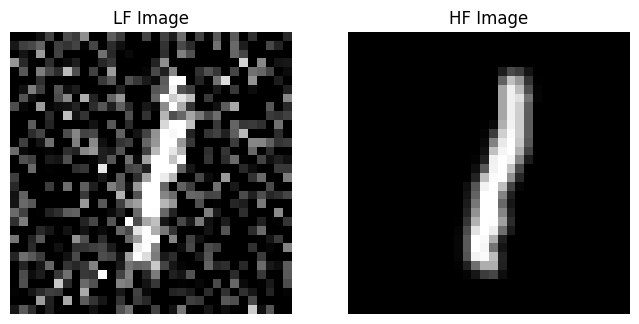

Label: 1


In [34]:
import matplotlib.pyplot as plt

lf, hf, lbl = val_ds[98]

# lf and hf are tensors, convert to numpy and squeeze if needed
lf_img = lf.squeeze().numpy()
hf_img = hf.squeeze().numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(lf_img, cmap='gray')
axs[0].set_title("LF Image")
axs[0].axis('off')

axs[1].imshow(hf_img, cmap='gray')
axs[1].set_title("HF Image")
axs[1].axis('off')

plt.show()

print("Label:", lbl)


In [1]:
from src.datasets import CropDataset
import numpy as np
import torch
from torchvision import transforms

train_ds = CropDataset(
    root="data",
    split="train"
)

test_ds = CropDataset(
    root="data",
    split="test"
)

val_ds = CropDataset(
    root="data",
    split="val"
)

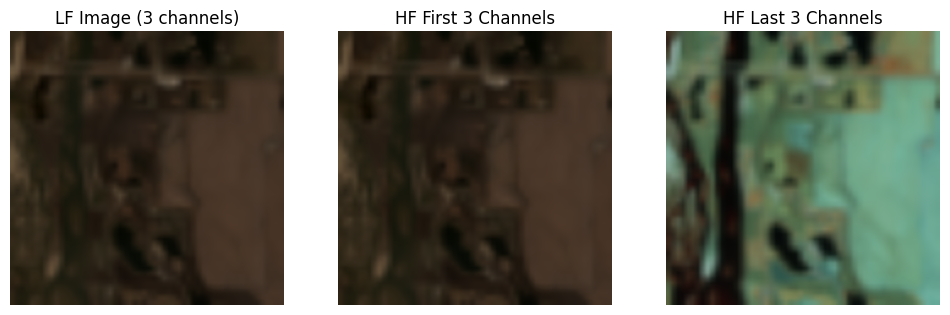

In [2]:
lf,hf,z = train_ds[0]

import matplotlib.pyplot as plt

# lf: (3, H, W), hf: (6, H, W) tensors

# Convert to numpy and transpose to (H, W, C)
lf_img = lf.permute(1, 2, 0).numpy()
hf_first3_img = hf[:3].permute(1, 2, 0).numpy()
hf_last3_img = hf[3:].permute(1, 2, 0).numpy()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(lf_img)
axs[0].set_title("LF Image (3 channels)")
axs[0].axis('off')

axs[1].imshow(hf_first3_img)
axs[1].set_title("HF First 3 Channels")
axs[1].axis('off')

axs[2].imshow(hf_last3_img)
axs[2].set_title("HF Last 3 Channels")
axs[2].axis('off')

plt.show()


float64


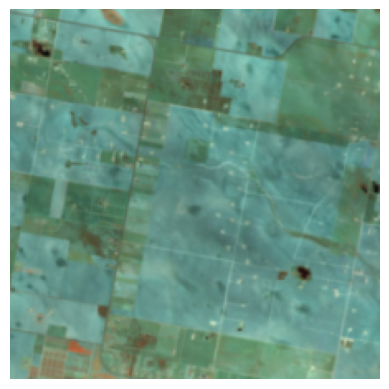

In [15]:
import tifffile as tif
import matplotlib.pyplot as plt

mask = tif.imread(r"D:\Documents\ML_Work\MetaLearner_V1\data\multi-temporal-crop-classification\training_chips\training_chips\chip_415_315.mask.tif")
image_set = tif.imread(r"D:\Documents\ML_Work\MetaLearner_V1\data\multi-temporal-crop-classification\training_chips\training_chips\chip_415_315_merged.tif")

# Normalize if needed
image_set = image_set / image_set.max()
print(image_set.dtype)

# Extract the first 3 channels: Blue, Green, Red
bgr = image_set[:, :, 3:6]

# Convert BGR to RGB by swapping channel 0 and 2
rgb = bgr[:, :, [0, 1, 2]]

plt.imshow(rgb)
plt.axis('off')
plt.show()

In [6]:
from src.datasets import CUBDataset
import numpy as np
import torch
from torchvision import transforms

train_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="train",
    seed=42
)

val_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="val",
    seed=42
)

test_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="test",
    seed=42
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00053254084..1.0000002].


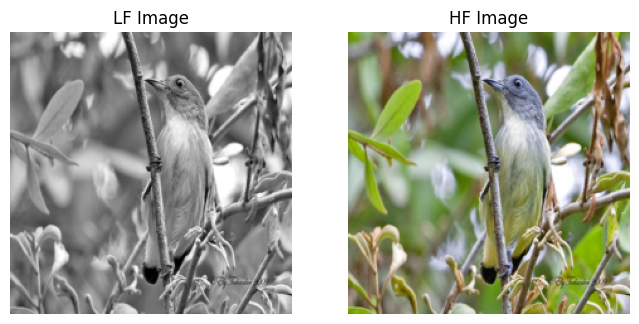

Label: 43


In [12]:
import matplotlib.pyplot as plt

lf, hf, lbl = val_ds[89]

# lf and hf are tensors, convert to numpy and squeeze if needed
lf_img = lf.squeeze().numpy()
hf_img = hf.squeeze().numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(lf_img, cmap='gray')
axs[0].set_title("LF Image")
axs[0].axis('off')

axs[1].imshow(hf_img.transpose(1,2,0))
axs[1].set_title("HF Image")
axs[1].axis('off')

plt.show()

print("Label:", lbl)


In [10]:
a = "045.Northern_Fulmar/Northern_Fulmar_0010_44112.jpg"

x = a.split(".")

label = int(x[0])

fname = ".".join(x[1:])

label, fname

(45, 'Northern_Fulmar/Northern_Fulmar_0010_44112.jpg')

In [1]:
from src.datasets import CUBDataset, FE_Dataset
from src.models import CustomResNet18
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import DataLoader


train_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="train",
    seed=42
)

val_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="val",
    seed=42
)

test_ds = CUBDataset(
    root="data/CUB_200_2011/CUB_200_2011",
    split="test",
    seed=42
)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16
)

test_loader = DataLoader(
    test_ds,
    batch_size=16
)

lf_model = CustomResNet18(
    latent_size=256,
    output_size=200,
    num_channels=1
)

hf_model = CustomResNet18(
    latent_size=256,
    output_size=200,
    num_channels=4
)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lf_model = lf_model.to(DEVICE)
hf_model = hf_model.to(DEVICE)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_lf = optim.Adam(lf_model.parameters(), lr=1e-3)
optimizer_hf = optim.Adam(hf_model.parameters(), lr=1e-3)

best_acc_lf = 0.0
best_acc_hf = 0.0

for epoch in range(1):
    # Training Step
    lf_model.train()
    hf_model.train()
    for lf, hf, labels in train_loader:
        lf = lf.to(DEVICE)
        hf = hf.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_lf.zero_grad()
        output_lf = lf_model(lf)[1]
        loss_lf = criterion(output_lf, labels)
        loss_lf.backward()
        optimizer_lf.step()

        optimizer_hf.zero_grad()
        hf_input = torch.cat([lf, hf], dim=1)
        output_hf = hf_model(hf_input)[1]
        loss_hf = criterion(output_hf, labels)
        loss_hf.backward()
        optimizer_hf.step()

    # Validation Step
    lf_model.eval()
    hf_model.eval()
    correct_lf = 0
    correct_hf = 0
    total = 0
    with torch.no_grad():
        for lf, hf, labels in val_loader:
            lf = lf.to(DEVICE)
            hf = hf.to(DEVICE)
            labels = labels.to(DEVICE)

            out_lf = lf_model(lf)[1]
            out_hf = hf_model(hf)[1]
            _, preds_lf = torch.max(out_lf, 1)
            _, preds_hf = torch.max(out_hf, 1)
            correct_lf += (preds_lf == labels).sum().item()
            correct_hf += (preds_hf == labels).sum().item()
            total += labels.size(0)

    val_acc_lf = correct_lf / total
    val_acc_hf = correct_hf / total

    if val_acc_lf > best_acc_lf:
        best_acc_lf = val_acc_lf
        torch.save(lf_model.state_dict(), 'best_lf_model.pt')

    if val_acc_hf > best_acc_hf:
        best_acc_hf = val_acc_hf
        torch.save(hf_model.state_dict(), 'best_hf_model.pt')

hf_model.load_state_dict(torch.load('best_hf_model.pt', weights_only=True))
lf_model.load_state_dict(torch.load('best_lf_model.pt', weights_only=True))

In [51]:
def create_fe_dataset(dataloader, lf_model, hf_model, device):
    lf_embeddings = []
    lf_preds = []
    hf_preds = []
    labels = []

    # Set models to eval mode
    lf_model.eval()
    hf_model.eval()

    lf_model.to(device)
    hf_model.to(device)

    with torch.no_grad():
        for lf_sample, hf_sample, label in dataloader:
            if device is not None:
                lf_sample = lf_sample.to(device)
                hf_sample = hf_sample.to(device)
                label = label.to(device)

            # LF model
            lf_outs = lf_model(lf_sample)
            lf_embed = lf_outs[0]
            lf_pred = lf_outs[-1]

            # HF model (concatenate lf_sample and hf_sample along last dim)
            hf_input = torch.cat([lf_sample, hf_sample], dim=1)
            hf_outs = hf_model(hf_input)
            hf_pred = hf_outs[-1]

            lf_embeddings.append(lf_embed.cpu())
            lf_preds.append(lf_pred.cpu())
            hf_preds.append(hf_pred.cpu())
            labels.append(label.cpu())

    # Concatenate all batches
    lf_embeddings = torch.cat(lf_embeddings, dim=0)
    lf_preds = torch.cat(lf_preds, dim=0)
    hf_preds = torch.cat(hf_preds, dim=0)
    labels = torch.cat(labels, dim=0)

    return FE_Dataset(lf_embeddings, lf_preds, hf_preds, labels)


In [52]:
fe_train_ds = create_fe_dataset(
    dataloader=train_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_val_ds = create_fe_dataset(
    dataloader=val_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_test_ds = create_fe_dataset(
    dataloader=test_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

fe_val_loader = DataLoader(
    val_ds,
    batch_size=64
)

fe_test_loader = DataLoader(
    test_ds,
    batch_size=64
)

In [53]:
def classifier_one_run(model, dataloader, criterion, fidelity, optimizer=None, scheduler=None):
    """
    Perform one run through the DataLoader.

    Args:
    - model (torch.nn.Module): The neural network model.
    - dataloader (DataLoader): The DataLoader for iterating over the dataset.
    - criterion (callable): The loss function.
    - optimizer (torch.optim.Optimizer, optional): The optimizer for updating model weights.

    Returns:
    - float: Average loss over the run.
    - int: Correct predictions for calculating accuracy if needed.
    """
    if fidelity not in ["lf", "hf", "gate"]:
        return

    model.train(mode=bool(optimizer))
    device = next(model.parameters()).device
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_high = 0
    if fidelity == "lf":
        for data, _, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)[-1]

            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "hf":
        for lf_data, hf_data, target in dataloader:
            target = target.type(torch.LongTensor)
            data = torch.cat([lf_data, hf_data], dim=1)

            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)[-1]
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "gate":
        for lf_embeddings, lf_preds, hf_preds, target in dataloader:
            lf_embeddings = lf_embeddings.to(device, torch.float)
            lf_preds = lf_preds.to(device, torch.float)
            hf_preds = hf_preds.to(device, torch.float)

            target = target.type(torch.LongTensor)
            target = target.to(device)

            outputs = model(lf_embeddings)[-1]
            preds = torch.stack([
                lf_preds,
                hf_preds
            ])

            loss = criterion(target, preds, outputs)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            choices = torch.argmax(outputs, dim=1)
            lf_acc = torch.argmax(lf_preds, dim=1) == target
            hf_acc = torch.argmax(hf_preds, dim=1) == target

            total_loss += loss.item() * lf_preds.size(0)
            total_correct += torch.sum(hf_acc[choices==1]) + torch.sum(lf_acc[choices==0]).item()
            total_samples += lf_preds.size(0)
            total_high += torch.sum(choices).item()
        if scheduler:
            scheduler.step()

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if fidelity=="gate":
        high_count = total_high / total_samples
        return average_loss, accuracy.item(), high_count

    return average_loss, accuracy


In [54]:
from src.models import CustomMLP
from src.losses import MetaLossFunction

for r in range(0, 101, 1):
    r_val = r / 100
    loss = MetaLossFunction(
        ch=[r_val],
        cw=1,
        device=DEVICE
    )

    fe_model = CustomMLP(
        input_size=32,
        num_layers=3,
        output_size=2
    )

    optimizer_fe = optim.Adam(fe_model.parameters(), lr=3e-4)

    val_min = 100000

    for i in range(100):
        train_loss, train_acc, train_count = classifier_one_run(
            model=fe_model,
            dataloader=fe_train_loader,
            criterion=loss,
            fidelity="gate",
            optimizer=optimizer_fe
        )

        val_loss, val_acc, val_count = classifier_one_run(
            model=fe_model,
            dataloader=fe_val_loader,
            criterion=loss,
            fidelity="gate",
        )

        if val_loss < val_min:
            torch.save(fe_model.state_dict(), 'best_fe_model.pt')

    fe_model.load_state_dict(torch.load('best_fe_model.pt', weights_only=True))

    test_loss, test_acc, test_count = classifier_one_run(
        model=fe_model,
        dataloader=fe_test_loader,
        criterion=loss,
        fidelity="gate",
    )

    print(round(r_val, 4), round(test_count, 4), round(test_loss, 4), round(test_acc, 4), sep="\t")

ValueError: not enough values to unpack (expected 4, got 3)

In [12]:
ch = [.5]
ch.insert(0,0)

ch_matrix = torch.tensor(ch)
ch_matrix = ch_matrix.view(-1, len(ch))
ch_matrix = ch_matrix.repeat(16, 1).T
ch_matrix

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
         0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000]])

In [9]:
from src.datasets import HypercubeDataset, FE_Dataset
import numpy as np
from torch.utils.data import DataLoader
from src.models import CustomMLP
import torch

train_ds = HypercubeDataset(
    num_dims=2,
    num_samples=np.array([51, 59, 82, 34]),
    hf_std=np.array([.1, .2, .25, .15]),
    lf_std=np.array([.2, .4, .8, .5])
)

test_ds = HypercubeDataset(
    num_dims=2,
    num_samples=np.array([5, 6, 10, 3]),
    hf_std=np.array([.1, .2, .25, .15]),
    lf_std=np.array([.2, .4, .8, .5])
)

val_ds = HypercubeDataset(
    num_dims=2,
    num_samples=np.array([10, 12, 15, 7]),
    hf_std=np.array([.1, .2, .25, .15]),
    lf_std=np.array([.2, .4, .8, .5])
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)
val_loader = DataLoader(val_ds, batch_size=16)

lf_model = CustomMLP(
    input_size=2,
    num_layers=2,
    output_size=4,
    hidden_size=32
)

hf_model = CustomMLP(
    input_size=4,
    num_layers=2,
    output_size=4,
    hidden_size=32
)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lf_model = lf_model.to(DEVICE)
hf_model = hf_model.to(DEVICE)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer_lf = optim.Adam(lf_model.parameters(), lr=1e-3)
optimizer_hf = optim.Adam(hf_model.parameters(), lr=1e-3)

best_acc_lf = 0.0
best_acc_hf = 0.0

for epoch in range(10):
    # Training Step
    lf_model.train()
    hf_model.train()
    for lf, hf, labels in train_loader:
        lf = lf.to(DEVICE)
        hf = hf.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_lf.zero_grad()
        output_lf = lf_model(lf)[1]
        loss_lf = criterion(output_lf, labels)
        loss_lf.backward()
        optimizer_lf.step()

        optimizer_hf.zero_grad()
        hf_input = torch.cat([lf, hf], dim=1)
        output_hf = hf_model(hf_input)[1]
        loss_hf = criterion(output_hf, labels)
        loss_hf.backward()
        optimizer_hf.step()

    # Validation Step
    lf_model.eval()
    hf_model.eval()
    correct_lf = 0
    correct_hf = 0
    total = 0
    with torch.no_grad():
        for lf, hf, labels in val_loader:
            lf = lf.to(DEVICE)
            hf = hf.to(DEVICE)
            hf_input = torch.cat([lf, hf], dim=1)
            labels = labels.to(DEVICE)

            out_lf = lf_model(lf)[1]
            out_hf = hf_model(hf_input)[1]
            _, preds_lf = torch.max(out_lf, 1)
            _, preds_hf = torch.max(out_hf, 1)
            correct_lf += (preds_lf == labels).sum().item()
            correct_hf += (preds_hf == labels).sum().item()
            total += labels.size(0)

    val_acc_lf = correct_lf / total
    val_acc_hf = correct_hf / total

    if val_acc_lf > best_acc_lf:
        best_acc_lf = val_acc_lf
        print("LF:", best_acc_lf)
        torch.save(lf_model.state_dict(), 'best_lf_model.pt')

    if val_acc_hf > best_acc_hf:
        best_acc_hf = val_acc_hf
        print("HF:", best_acc_hf)
        torch.save(hf_model.state_dict(), 'best_hf_model.pt')

hf_model.load_state_dict(torch.load('best_hf_model.pt', weights_only=True))
lf_model.load_state_dict(torch.load('best_lf_model.pt', weights_only=True))

LF: 0.4318181818181818
HF: 0.36363636363636365
LF: 0.6136363636363636
HF: 0.6136363636363636
LF: 0.7727272727272727
HF: 0.6818181818181818
HF: 0.7727272727272727
HF: 0.8409090909090909


<All keys matched successfully>

In [11]:
def create_fe_dataset(dataloader, lf_model, hf_model, device):
    lf_embeddings = []
    lf_preds = []
    hf_preds = []
    labels = []

    # Set models to eval mode
    lf_model.eval()
    hf_model.eval()

    lf_model.to(device)
    hf_model.to(device)

    with torch.no_grad():
        for lf_sample, hf_sample, label in dataloader:
            if device is not None:
                lf_sample = lf_sample.to(device)
                hf_sample = hf_sample.to(device)
                label = label.to(device)

            # LF model
            lf_outs = lf_model(lf_sample)
            lf_embed = lf_outs[0]
            lf_pred = lf_outs[-1]

            # HF model (concatenate lf_sample and hf_sample along last dim)
            hf_input = torch.cat([lf_sample, hf_sample], dim=1)
            hf_outs = hf_model(hf_input)
            hf_pred = hf_outs[-1]

            lf_embeddings.append(lf_embed.cpu())
            lf_preds.append(lf_pred.cpu())
            hf_preds.append(hf_pred.cpu())
            labels.append(label.cpu())

    # Concatenate all batches
    lf_embeddings = torch.cat(lf_embeddings, dim=0)
    lf_preds = torch.cat(lf_preds, dim=0)
    hf_preds = torch.cat(hf_preds, dim=0)
    labels = torch.cat(labels, dim=0)
    print(lf_embeddings.shape)

    return FE_Dataset(lf_embeddings, lf_preds, hf_preds, labels)


In [12]:
fe_train_ds = create_fe_dataset(
    dataloader=train_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_val_ds = create_fe_dataset(
    dataloader=val_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_test_ds = create_fe_dataset(
    dataloader=test_loader,
    lf_model=lf_model,
    hf_model=hf_model,
    device=DEVICE
)

fe_train_loader = DataLoader(
    fe_train_ds,
    batch_size=32,
    shuffle=True
)

fe_val_loader = DataLoader(
    fe_val_ds,
    batch_size=64
)

fe_test_loader = DataLoader(
    fe_test_ds,
    batch_size=64
)

torch.Size([226, 32])
torch.Size([44, 32])
torch.Size([24, 32])


In [13]:
for i in fe_train_loader:
    print(len(i))
    print(i[0].shape, i[1].shape, i[2].shape)
    break

4
torch.Size([32, 32]) torch.Size([32, 4]) torch.Size([32, 4])


In [14]:
def classifier_one_run(model, dataloader, criterion, fidelity, optimizer=None, scheduler=None):
    """
    Perform one run through the DataLoader.

    Args:
    - model (torch.nn.Module): The neural network model.
    - dataloader (DataLoader): The DataLoader for iterating over the dataset.
    - criterion (callable): The loss function.
    - optimizer (torch.optim.Optimizer, optional): The optimizer for updating model weights.

    Returns:
    - float: Average loss over the run.
    - int: Correct predictions for calculating accuracy if needed.
    """
    if fidelity not in ["lf", "hf", "gate"]:
        return

    model.train(mode=bool(optimizer))
    device = next(model.parameters()).device
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_high = 0
    if fidelity == "lf":
        for data, _, target in dataloader:
            target = target.type(torch.LongTensor)
            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)[-1]

            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "hf":
        for lf_data, hf_data, target in dataloader:
            target = target.type(torch.LongTensor)
            data = torch.cat([lf_data, hf_data], dim=1)

            data, target = data.to(device, torch.float), target.to(device)
            output = model(data)[-1]
            loss = criterion(output, target)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * data.size(0)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == target).sum().item()
            total_samples += data.size(0)
        if scheduler:
            scheduler.step()

    elif fidelity == "gate":
        for lf_embeddings, lf_preds, hf_preds, target in dataloader:
            lf_embeddings = lf_embeddings.to(device, torch.float)
            lf_preds = lf_preds.to(device, torch.float)
            hf_preds = hf_preds.to(device, torch.float)

            target = target.type(torch.LongTensor)
            target = target.to(device)

            outputs = model(lf_embeddings)[-1]
            preds = torch.stack([
                lf_preds,
                hf_preds
            ])

            loss = criterion(target, preds, outputs)
            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            choices = torch.argmax(outputs, dim=1)
            lf_acc = torch.argmax(lf_preds, dim=1) == target
            hf_acc = torch.argmax(hf_preds, dim=1) == target

            total_loss += loss.item() * lf_preds.size(0)
            total_correct += torch.sum(hf_acc[choices==1]) + torch.sum(lf_acc[choices==0]).item()
            total_samples += lf_preds.size(0)
            total_high += torch.sum(choices).item()
        if scheduler:
            scheduler.step()

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if fidelity=="gate":
        high_count = total_high / total_samples
        return average_loss, accuracy.item(), high_count

    return average_loss, accuracy


In [15]:
from src.models import CustomMLP
from src.losses import MetaLossFunction

for r in range(0, 101, 1):
    r_val = r / 100
    loss = MetaLossFunction(
        ch=[r_val],
        cw=1,
        device=DEVICE
    )

    fe_model = CustomMLP(
        input_size=32,
        num_layers=3,
        output_size=2
    )

    optimizer_fe = optim.Adam(fe_model.parameters(), lr=3e-4)

    val_min = 100000

    for i in range(100):
        train_loss, train_acc, train_count = classifier_one_run(
            model=fe_model,
            dataloader=fe_train_loader,
            criterion=loss,
            fidelity="gate",
            optimizer=optimizer_fe
        )

        val_loss, val_acc, val_count = classifier_one_run(
            model=fe_model,
            dataloader=fe_val_loader,
            criterion=loss,
            fidelity="gate",
        )

        if val_loss < val_min:
            torch.save(fe_model.state_dict(), 'best_fe_model.pt')

    fe_model.load_state_dict(torch.load('best_fe_model.pt', weights_only=True))

    test_loss, test_acc, test_count = classifier_one_run(
        model=fe_model,
        dataloader=fe_test_loader,
        criterion=loss,
        fidelity="gate",
    )

    print(round(r_val, 4), round(test_count, 4), round(test_loss, 4), round(test_acc, 4), sep="\t")

0.0	1.0	0.4546	0.875
0.01	1.0	0.4592	0.875
0.02	1.0	0.4637	0.875
0.03	1.0	0.4683	0.875
0.04	1.0	0.4728	0.875
0.05	1.0	0.4774	0.875
0.06	1.0	0.4819	0.875
0.07	1.0	0.4865	0.875
0.08	1.0	0.491	0.875
0.09	1.0	0.4956	0.875
0.1	1.0	0.5001	0.875
0.11	1.0	0.5046	0.875
0.12	1.0	0.5092	0.875
0.13	1.0	0.5137	0.875
0.14	1.0	0.5183	0.875
0.15	1.0	0.5228	0.875
0.16	1.0	0.5274	0.875
0.17	1.0	0.5319	0.875
0.18	1.0	0.5365	0.875
0.19	1.0	0.541	0.875
0.2	1.0	0.5456	0.875
0.21	1.0	0.5501	0.875
0.22	1.0	0.5547	0.875
0.23	1.0	0.5592	0.875
0.24	1.0	0.5638	0.875
0.25	1.0	0.5683	0.875
0.26	1.0	0.5728	0.875
0.27	1.0	0.5774	0.875
0.28	1.0	0.5819	0.875
0.29	1.0	0.5865	0.875
0.3	1.0	0.591	0.875
0.31	1.0	0.5956	0.875
0.32	1.0	0.6001	0.875
0.33	1.0	0.6047	0.875
0.34	1.0	0.6092	0.875
0.35	1.0	0.6138	0.875
0.36	1.0	0.6183	0.875
0.37	1.0	0.6229	0.875
0.38	1.0	0.6274	0.875
0.39	1.0	0.6319	0.875
0.4	1.0	0.6365	0.875
0.41	1.0	0.641	0.875
0.42	1.0	0.6456	0.875
0.43	1.0	0.6501	0.875
0.44	1.0	0.6547	0.875
0.45	1.0	0.6592	0.8